In [14]:
from dotenv import load_dotenv
from matplotlib import pyplot as plt
import os

load_dotenv()  # take environment variables from .env.

True

In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, EstimatorV2 as Estimator

In [16]:
service = QiskitRuntimeService(
    channel="ibm_quantum_platform", # optional
    token=os.getenv("QISKIT_IBM_TOKEN"),
    instance=os.getenv("QISKIT_IBM_CRN")
)

qiskit_runtime_service._discover_account:WARNING:2026-03-23 17:12:35,969: Loading account with the given token. A saved account will not be used.


### First simple circuit perform quantum accurate coin toss

In [17]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

In [18]:
qc = QuantumCircuit(1,1)

qc.h(0)
qc.measure(0,0)

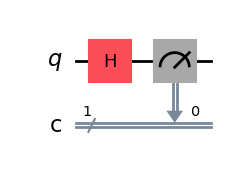

In [19]:
qc.draw('mpl')

In [20]:
# 2: Optimize problem for real hardware execution.
from qiskit.transpiler import generate_preset_pass_manager

backend = service.least_busy(operational=True, simulator=False)
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

In [21]:
# 3. Execute using the Sampler primitive
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024  # Options can be set using auto-complete.
job = sampler.run([isa_circuit])
print(f"Job ID is {job.job_id()}")

Job ID is d70n93s69uic73ckicrg


In [22]:
pub_result = job.result()[0]
print(f"Counts for the output register: {pub_result.data['c'].get_counts()}")

Counts for the output register: {'0': 500, '1': 524}


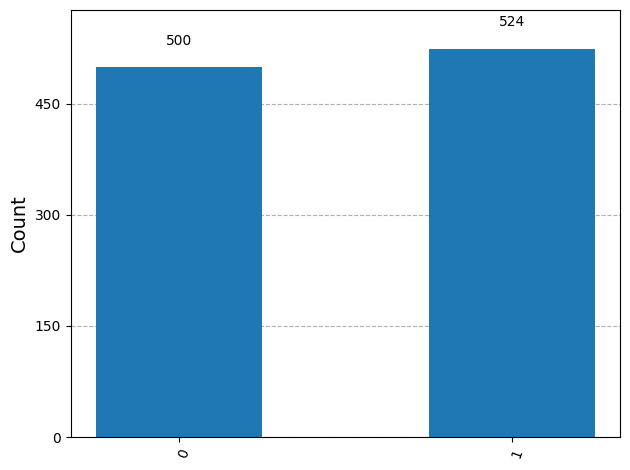

In [23]:
from qiskit.visualization import plot_histogram

plot_histogram(pub_result.data['c'].get_counts())

### lets check the gate maps ;)

In [24]:
from qiskit.visualization import plot_gate_map

In [29]:
print(f"Name: {backend.name}, {backend.num_qubits}, {backend.provider}, {backend.version}")

Name: ibm_torino, 133, None, 2


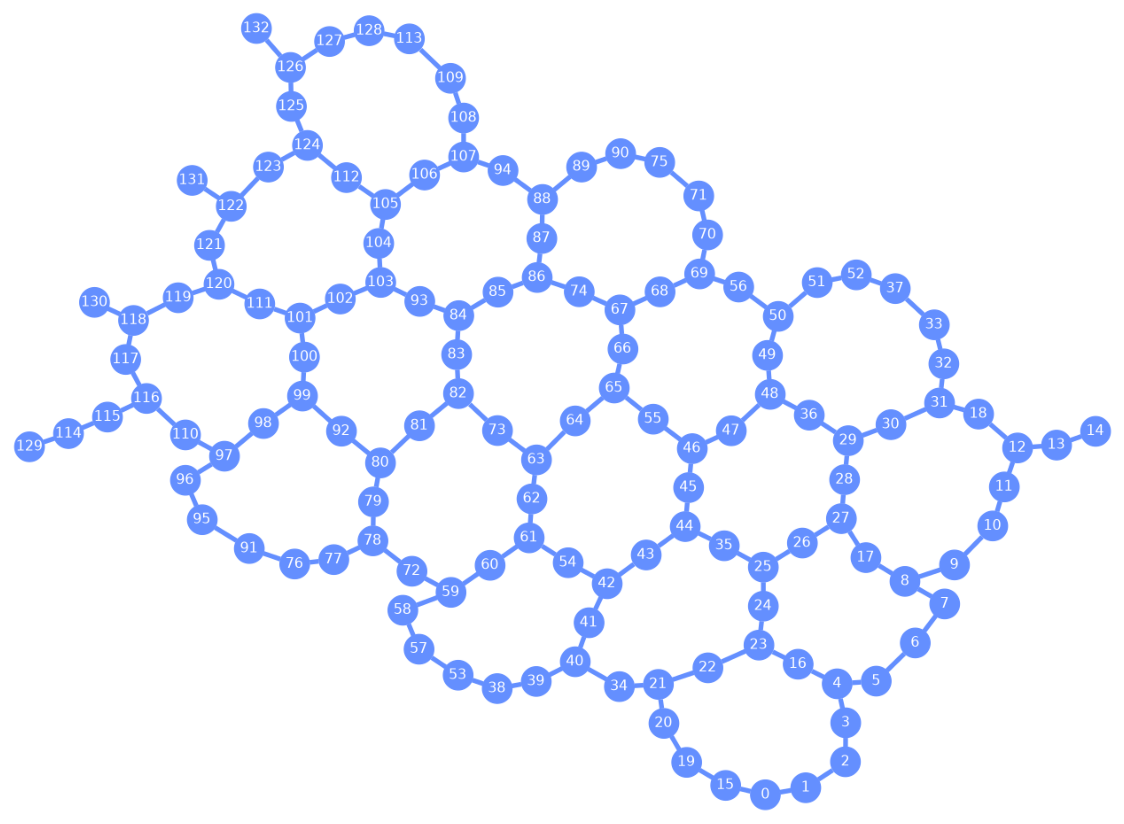

In [25]:
plot_gate_map(backend)

Lets make the low effort to call a circuit for fast iterations

In [39]:
def run_real_hardware(qc: QuantumCircuit, shorts: int=1024) -> tuple[str, any]:
    b = service.least_busy(operational=True, simulator=False)
    pm = generate_preset_pass_manager(backend=b, optimization_level=1)
    isa_circuit = pm.run(qc)
    
    sampler = Sampler(mode=b)
    sampler.options.default_shots = shorts  # Options can be set using auto-complete.
    job = sampler.run([isa_circuit])
    return job.job_id(), job.result()
    

## Lets check how can qubits can talk with each others and give interesting properties like
Like you one bro is at `|0>` then another will behave as `|0>` and if the first bro is at `|1>` then second one be like I am going to behave the same `|1>`

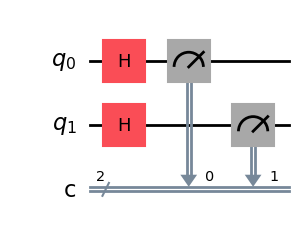

In [37]:
qc = QuantumCircuit(2, 2)
qc.h(0)  # Qubit 0 in superposition
qc.h(1)  # Qubit 1 in superposition (independently)
qc.measure([0, 1], [0, 1])
qc.draw('mpl')

In [40]:
run_id, res = run_real_hardware(qc, 1024)
print(f"Run Id=> {run_id}, Result=> {res[0].data['c'].get_counts()}")

Run Id=> d70nl1k69uic73ckisg0, Result=> {'11': 237, '01': 225, '00': 270, '10': 292}


now lets make the combination of `|00>` and `|11>` only possible

In [42]:
qc_full = QuantumCircuit(2, 2)
qc_full.h(0)
qc_full.cx(0, 1)  # CNOT creates entanglement
qc_full.measure_all()
qc_full.draw()

┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
   c: 2/══════════════╬══╬═
                      ║  ║ 
meas: 2/══════════════╩══╩═
                      0  1

In [43]:
run_id, res = run_real_hardware(qc_full, 1024)
print(f"Run Id=> {run_id}, Result=> {res[0].data.meas.get_counts()}")

Run Id=> d70nm8af84ks73dgjkpg, Result=> {'11': 440, '00': 482, '10': 53, '01': 49}


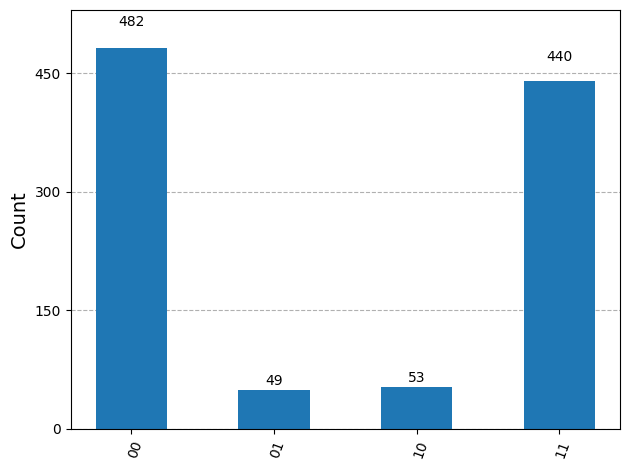

In [44]:
plot_histogram(res[0].data.meas.get_counts())

## lets get a real world example for the estimator and how we use it

In [49]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# "ZZ" asks: "Are both qubits always identical?"
obs_ZZ = SparsePauliOp("ZZ")
# "ZI" asks: "Is Qubit 1 leaning towards 0 or 1?" (Ignoring Qubit 0)
obs_ZI = SparsePauliOp("ZI")
# "IZ" asks: "Is Qubit 0 leaning towards 0 or 1?" (Ignoring Qubit 1)
obs_IZ = SparsePauliOp("IZ")

# Get Backend and Transpile
b = service.least_busy(operational=True, simulator=False)
pm = generate_preset_pass_manager(backend=b, optimization_level=1)

isa_circuit = pm.run(qc)
isa_obs_ZZ = obs_ZZ.apply_layout(isa_circuit.layout)
isa_obs_ZI = obs_ZI.apply_layout(isa_circuit.layout)
isa_obs_IZ = obs_IZ.apply_layout(isa_circuit.layout)

# Estimator
estimator = Estimator(mode=b)

# Notice we pass a LIST of observables to the PUB
job = estimator.run([(isa_circuit, [isa_obs_ZZ, isa_obs_ZI, isa_obs_IZ])])
print(f"Job running... ID: {job.job_id()}")

result = job.result()[0] # Get the result for our single PUB
evs = result.data.evs    # This is an array of the 3 scores

print("\n--- THE RESULTS ---")
print(evs)

Job running... ID: d70o84qtnsts73euh1q0

--- THE RESULTS ---
[ 0.95135983 -0.01792459  0.00199539]


The Estimator just does the math for you and spits out the physical truth:
   1. ZZ ~ 1.0: They are practically locked together.
   2. ZI ~ 0.0: Qubit 1 is a coin toss.
   3. IZ ~ 0.0: Qubit 0 is a coin toss.

  This is exactly what Einstein called "spooky action at a distance". The individuals are completely random, but the system is perfectly synchronized! And the Estimator gave you the exact three
  numbers to prove it without you needing to read a histogram.
  

## lets move ahead of ourselves and checkout how do we teleport information

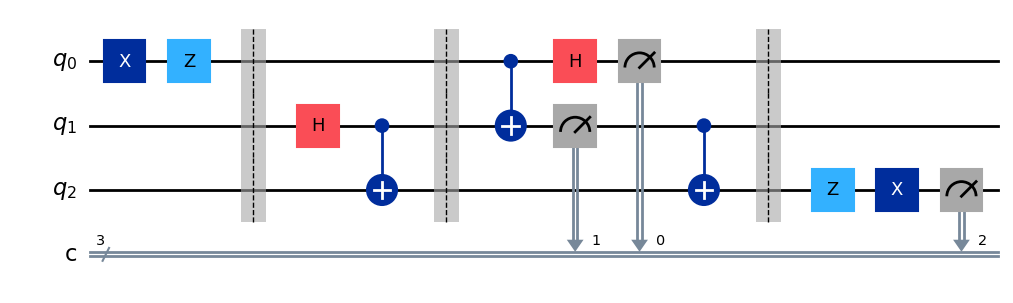

In [50]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(3, 3)

# Step 1: Alice prepares the state she wants to teleport
# (X and Z gates put qubit 0 in a specific state)
qc.x(0)
qc.z(0)
qc.barrier()

# Step 2: Create an entangled pair (qubits 1 and 2)
# Qubit 1 goes to Alice, qubit 2 goes to Bob
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# Step 3: Alice entangles her state with her half of the pair
qc.cx(0, 1)
qc.h(0)
qc.measure(0, 0)
qc.measure(1, 1)

# Step 4: Bob applies corrections based on Alice's measurements
qc.cx(1, 2)
qc.barrier()

# Step 5: Verify — reverse the original preparation on Bob's qubit
# If teleportation worked, this should return |0⟩
qc.z(2)
qc.x(2)
qc.measure(2, 2)

qc.draw('mpl')

In [51]:
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
print(result.get_counts())

{'001': 274, '010': 246, '000': 259, '011': 245}


In [52]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from math import pi

theta = pi / 3  # 60 degrees

qc = QuantumCircuit(3, 3)

# Alice prepares an arbitrary state: Ry(60°) on q0
qc.ry(theta, 0)
qc.barrier()

# Shared entangled pair
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# Alice's operations
qc.cx(0, 1)
qc.h(0)
qc.measure(0, 0)
qc.measure(1, 1)

# Bob's corrections — BOTH needed for arbitrary states
qc.cx(1, 2)   # X correction based on Alice's q1
qc.cz(0, 2)   # Z correction based on Alice's q0
qc.barrier()

# Measure Bob's qubit directly
qc.measure(2, 2)

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()
print(counts)

{'100': 66, '001': 188, '101': 63, '110': 55, '111': 70, '011': 204, '000': 196, '010': 182}


Alice's state: Statevector([0.8660254+0.j, 0.5      +0.j],
            dims=(2,))
Probabilities: |0⟩ = 0.7500, |1⟩ = 0.2500


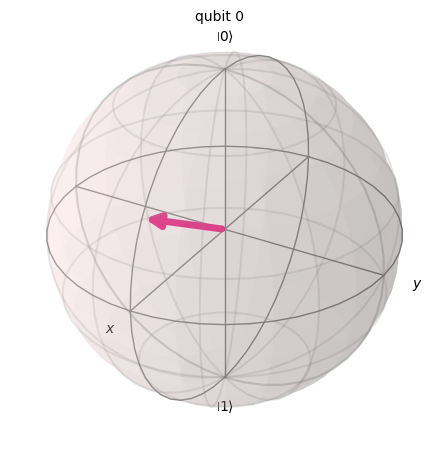

In [74]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from math import pi

theta = pi / 3  # 60 degrees

# ============================================
# ALICE'S STATE — exact theoretical statevector
# ============================================
qc_alice = QuantumCircuit(1)
qc_alice.ry(theta, 0)
alice_state = Statevector.from_instruction(qc_alice)
alice_probs = alice_state.probabilities()
print("Alice's state:", alice_state)
print(f"Probabilities: |0⟩ = {alice_probs[0]:.4f}, |1⟩ = {alice_probs[1]:.4f}")
plot_bloch_multivector(alice_state)


In [75]:
# ============================================
# TELEPORTATION CIRCUIT
# ============================================
qc = QuantumCircuit(3, 3)

# Alice prepares the same state on q0
qc.ry(theta, 0)
qc.barrier()

# Shared entangled pair (q1 = Alice's half, q2 = Bob's half)
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# Alice's operations
qc.cx(0, 1)
qc.h(0)
qc.measure(0, 0)
qc.measure(1, 1)

# Bob's corrections (both needed for arbitrary states)
qc.cx(1, 2)
qc.cz(0, 2)
qc.barrier()

# Measure Bob's qubit
qc.measure(2, 2)

print("\nCircuit:")
print(qc.draw())


Circuit:
     ┌─────────┐ ░            ░      ┌───┐┌─┐         ░    
q_0: ┤ Ry(π/3) ├─░────────────░───■──┤ H ├┤M├──────■──░────
     └─────────┘ ░ ┌───┐      ░ ┌─┴─┐└┬─┬┘└╥┘      │  ░    
q_1: ────────────░─┤ H ├──■───░─┤ X ├─┤M├──╫───■───┼──░────
                 ░ └───┘┌─┴─┐ ░ └───┘ └╥┘  ║ ┌─┴─┐ │  ░ ┌─┐
q_2: ────────────░──────┤ X ├─░────────╫───╫─┤ X ├─■──░─┤M├
                 ░      └───┘ ░        ║   ║ └───┘    ░ └╥┘
c: 3/══════════════════════════════════╩═══╩═════════════╩═
                                       1   0             2 


In [76]:
# ============================================
# RUN AND VERIFY
# ============================================
simulator = AerSimulator()
result = simulator.run(qc, shots=4096).result()
counts = result.get_counts()
print("\nRaw counts:", counts)

# Sum up Bob's qubit (leftmost bit in Qiskit convention)
bob_0 = sum(v for k, v in counts.items() if k[0] == '0')
bob_1 = sum(v for k, v in counts.items() if k[0] == '1')
total = bob_0 + bob_1



Raw counts: {'100': 256, '001': 737, '111': 258, '011': 799, '101': 265, '110': 263, '010': 754, '000': 764}



--- RESULTS ---
Alice's state:   0.8660+0.0000j|0⟩ + 0.5000+0.0000j|1⟩
Alice's probs:   |0⟩ = 0.7500, |1⟩ = 0.2500
Bob's measured:  |0⟩ = 0.7456 (3054/4096), |1⟩ = 0.2544 (1042/4096)


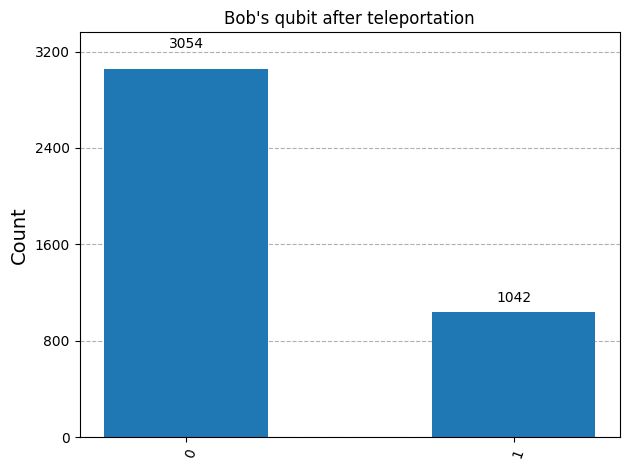

In [78]:
print(f"\n--- RESULTS ---")
print(f"Alice's state:   {alice_state[0]:.4f}|0⟩ + {alice_state[1]:.4f}|1⟩")
print(f"Alice's probs:   |0⟩ = {alice_probs[0]:.4f}, |1⟩ = {alice_probs[1]:.4f}")
print(f"Bob's measured:  |0⟩ = {bob_0/total:.4f} ({bob_0}/{total}), |1⟩ = {bob_1/total:.4f} ({bob_1}/{total})")

# Histogram of just Bob's qubit
bob_counts = {'0': bob_0, '1': bob_1}
plot_histogram(bob_counts, title="Bob's qubit after teleportation")


Now lets run the same experiment on real hardware

In [79]:
job_id, result = run_real_hardware(qc, shorts=4096)
print(f"Job ID: {job_id}")

Job ID: d70pjis69uic73ckl1eg


In [80]:
counts = result[0].data.c.get_counts()
print("Raw counts:", counts)

Raw counts: {'101': 269, '110': 296, '111': 257, '010': 763, '011': 695, '000': 755, '001': 776, '100': 285}


In [81]:
# Same Bob extraction logic works
bob_0 = sum(v for k, v in counts.items() if k[0] == '0')
bob_1 = sum(v for k, v in counts.items() if k[0] == '1')
total = bob_0 + bob_1

print(f"Alice's probs:   |0⟩ = {alice_probs[0]:.4f}, |1⟩ = {alice_probs[1]:.4f}")
print(f"Bob's measured:  |0⟩ = {bob_0/total:.4f}, |1⟩ = {bob_1/total:.4f}")

Alice's probs:   |0⟩ = 0.7500, |1⟩ = 0.2500
Bob's measured:  |0⟩ = 0.7297, |1⟩ = 0.2703


The real hardware is only ~2% off from ideal. That's impressively close — the noise shifted things slightly toward 50/50 (which is what noise does, it randomizes), but the signal is clearly there.